In [3]:
df  = pd.read_csv('/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv')

In [4]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [5]:
X = df.iloc[:,0:2]
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [6]:
y = df.iloc[:,2]
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [13]:
import tensorflow
from tensorflow.keras.layers import Dense 
from tensorflow.keras import Sequential

In [14]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-10 13:36:02.276466: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [23]:
history_without_scaling = model.fit(X_train,y_train,validation_split=0.2,epochs=300)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4414 - loss: 76.1747 - val_accuracy: 0.6875 - val_loss: 53.8672
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5273 - loss: 63.1920 - val_accuracy: 0.6875 - val_loss: 54.4334
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5469 - loss: 50.9927 - val_accuracy: 0.6875 - val_loss: 94.5235
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4336 - loss: 89.6126 - val_accuracy: 0.6875 - val_loss: 31.6699
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5391 - loss: 25.0308 - val_accuracy: 0.3125 - val_loss: 44.5125
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4688 - loss: 21.8667 - val_accuracy: 0.2969 - val_loss: 7.9350
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5039 - loss: 21.1146 - val_accuracy: 0.2969 - val_loss: 8.6002
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5273 - loss: 15.9016 - val_accuracy: 0.312

Text(0.5, 1.0, 'Accuracy without Scaling')

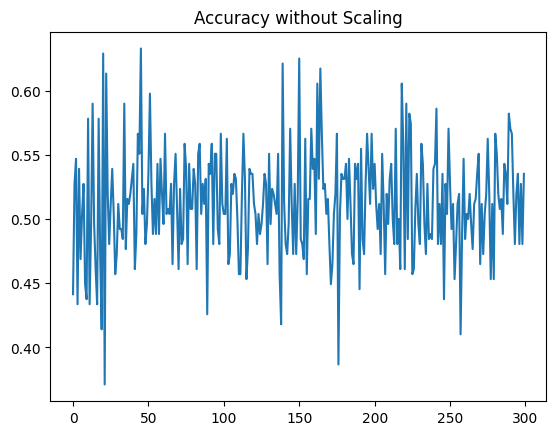

In [35]:
import matplotlib.pyplot as plt
plt.plot(history_without_scaling.history['accuracy'])
plt.title('Accuracy without Scaling')

# Here the data scale is too large from each other, so we apply Feature Scaling
We do feature scaling beacuse the model give more value to the salary beacuse it give big update but both feature is important so we do feature scaling

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [32]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
history_with_scaling = model.fit(X_train_scaled,y_train,validation_split=0.2,epochs=300)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6289 - loss: 1.0819 - val_accuracy: 0.6875 - val_loss: 0.8623
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6289 - loss: 0.9531 - val_accuracy: 0.6875 - val_loss: 0.7434
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6406 - loss: 0.8060 - val_accuracy: 0.7656 - val_loss: 0.6182
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7383 - loss: 0.6411 - val_accuracy: 0.7656 - val_loss: 0.5030
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7695 - loss: 0.5155 - val_accuracy: 0.7656 - val_loss: 0.4089
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8047 - loss: 0.4199 - val_accuracy: 0.8281 - val_loss: 0.3533
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8320 - loss: 0.3685 - val_accuracy: 0.8281 - val_loss: 0.3274
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8516 - loss: 0.3374 - val_accuracy: 0.8750 - val_loss:

Text(0.5, 1.0, 'Accuracy with Scaling ')

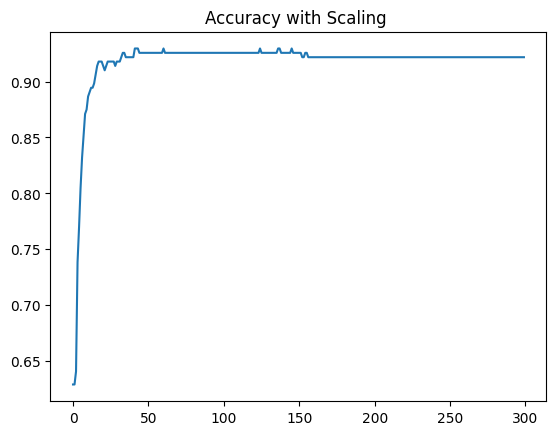

In [36]:
import matplotlib.pyplot as plt
plt.plot(history_with_scaling.history['accuracy'])
plt.title('Accuracy with Scaling ')